# Penjelasan Dataset

| Nama Variabel | Tipe Data   | Deskripsi                                                                                                                |
| ------------- | ----------- | ------------------------------------------------------------------------------------------------------------------------ |
| **age**       | Integer     | Usia pemegang asuransi utama dalam satuan tahun                                                                          |
| **sex**       | Category | Jenis kelamin pemegang asuransi dengan kategori **male** dan **female**                                                  |
| **bmi**       | Float       | Body Mass Index (BMI) yang menunjukkan kondisi berat badan individu                                                      |
| **children**  | Integer     | Jumlah anak atau tanggungan yang ditanggung asuransi, dengan nilai **0–5**                                               |
| **smoker**    | Category | Status kebiasaan merokok pemegang asuransi dengan kategori **yes** dan **no**                                            |
| **region**    | Category | Wilayah tempat tinggal pemegang asuransi di Amerika Serikat, <br> meliputi **northeast, southeast, southwest, dan northwest** |
| **charges**   | Float       | Total biaya medis individu yang ditagihkan oleh asuransi kesehatan                                                       |


# Import Data

## Library yang digunakan

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
import matplotlib.pyplot as plt
from scipy.stats import probplot
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

## Load data

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## info Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Menampilkan ringkasan statistik

In [5]:
df.describe(include=['int64', 'float64'])

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Memeriksa data kosong

In [6]:
pd.isnull(df).sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Memeriksa duplikasi data

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
def show_duplicates(df, subset=None, keep=False):
    """
    Menampilkan baris duplikat dari DataFrame.
    
    Parameters:
        df (pd.DataFrame): Data yang akan diperiksa.
        subset (list/str, optional): Kolom atau daftar kolom yang diperiksa duplikatnya.
        keep (str/bool, optional): 
            - 'first' : tandai duplikat setelah kemunculan pertama
            - 'last'  : tandai duplikat sebelum kemunculan terakhir
            - False   : tandai semua duplikat
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input harus berupa pandas DataFrame.")
    
    duplicates = df[df.duplicated(subset=subset, keep=keep)]
    return duplicates

# Menampilkan semua baris yang duplikat berdasarkan semua kolom
print("\nData duplikat (berdasarkan semua kolom):")
print(show_duplicates(df, keep=False))


Data duplikat (berdasarkan semua kolom):
     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


In [9]:
duplicates = df[df.duplicated()]
print(duplicates)

     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631


In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
len(df)

1337

## Distribusi data

In [12]:
# Uji normalitas untuk age
stat_age, p_age = shapiro(df['age'].dropna()) # hanya kolom `age` yang diambil selain itu tidak
print("Age")
print(f"  Statistik uji : {stat_age:.4f}")
print(f"  p-value : {p_age:.4f}")
if p_age > 0.05:
    print("Data berdistribusi normal\n")
else:
    print("Data tidak berdistribusi normal\n")


# Uji normalitas untuk charges
stat_glucose, p_glucose = shapiro(df['charges'].dropna()) # hanya kolom `avg_glucose_level` yang diambil selain itu tidak
print("charges")
print(f"  Statistik uji : {stat_glucose:.4f}")
print(f"  p-value : {p_glucose:.4f}")
if p_glucose > 0.05:
    print("Data berdistribusi normal\n")
else:
    print("Data tidak berdistribusi normal\n")


# Uji normalitas untuk bmi
stat_bmi, p_bmi = shapiro(df['bmi'].dropna()) # hanya kolom `bmi` yang diambil selain itu tidak
print("BMI")
print(f"  Statistik uji : {stat_bmi:.4f}")
print(f"  p-value : {p_bmi:.4f}")
if p_bmi > 0.05:
    print("Data berdistribusi normal\n")
else:
    print("Data tidak berdistribusi normal\n")

Age
  Statistik uji : 0.9449
  p-value : 0.0000
Data tidak berdistribusi normal

charges
  Statistik uji : 0.8148
  p-value : 0.0000
Data tidak berdistribusi normal

BMI
  Statistik uji : 0.9939
  p-value : 0.0000
Data tidak berdistribusi normal



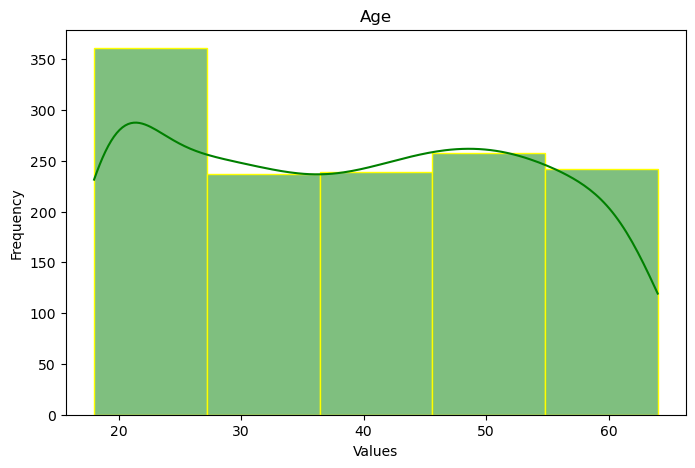

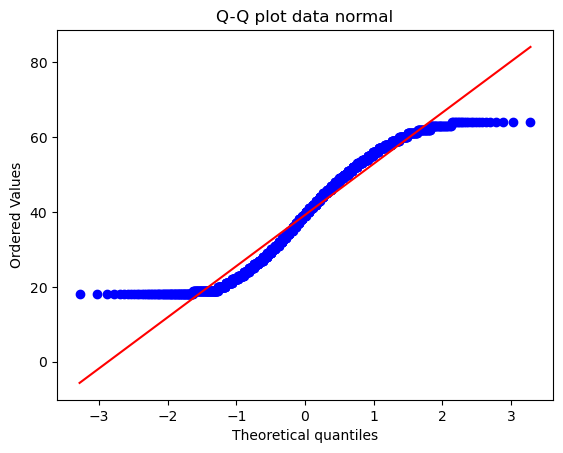

In [14]:
# Membuat histogram untuk melihat distribusi nilai umur
plt.figure(figsize=(8,5)) # Mengatur ukuran figure
sns.histplot(df['age'], bins=5, kde=True, color='green', edgecolor='yellow')  # bins = 5 artinya membagi umur menjadi 5 interval
plt.xlabel('Values')   # Label sumbu X
plt.ylabel('Frequency')  # Label sumbu Y
plt.title('Age')       # Judul histogram
plt.show()             # Menampilkan histogram

# Membuat Q-Q plot untuk memeriksa normalitas data umur
probplot(df["age"], dist="norm", plot=plt)  # Membandingkan distribusi umur dengan distribusi normal
plt.title("Q-Q plot data normal")  # Judul Q-Q plot
plt.show()  # Menampilkan Q-Q plot


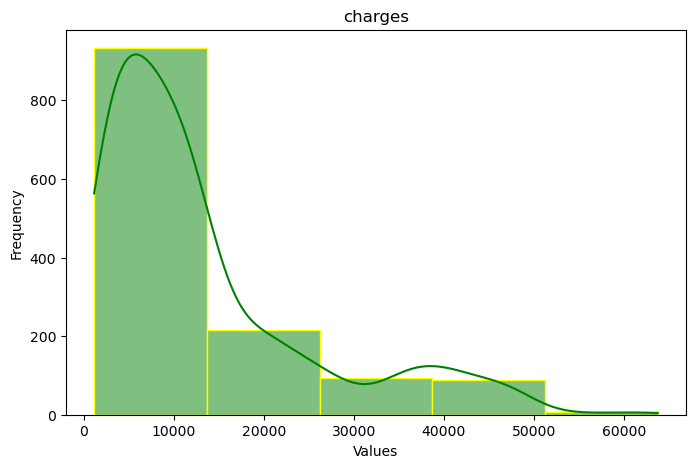

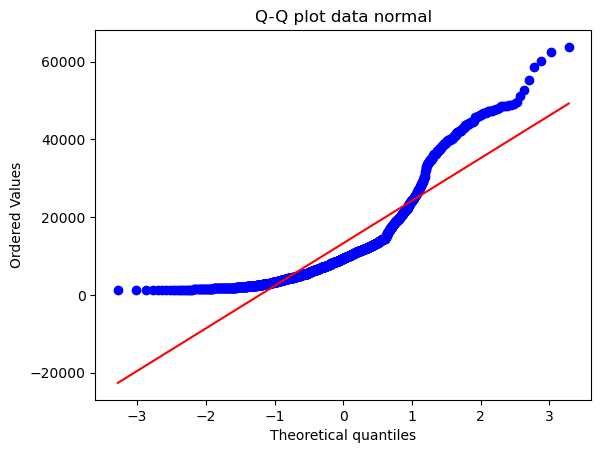

In [15]:
# Membuat histogram untuk melihat distribusi avg_glucose_level
plt.figure(figsize=(8,5)) #  Mengatur ukuran figure
sns.histplot(df['charges'], bins=5, kde=True, color='green', edgecolor='yellow') # bins=5 artinya membagi avg_glucose_level menjadi 5 interval
plt.xlabel('Values')   # Label sumbu X
plt.ylabel('Frequency')  # Label sumbu Y
plt.title('charges')       # Judul histogram
plt.show()             # Menampilkan histogram

# Membuat Q-Q plot untuk memeriksa normalitas avg_glucose_level
probplot(df["charges"], dist="norm", plot=plt)  # Membandingkan distribusi umur dengan distribusi normal
plt.title("Q-Q plot data normal")  # Judul Q-Q plot
plt.show()  # Menampilkan Q-Q plot


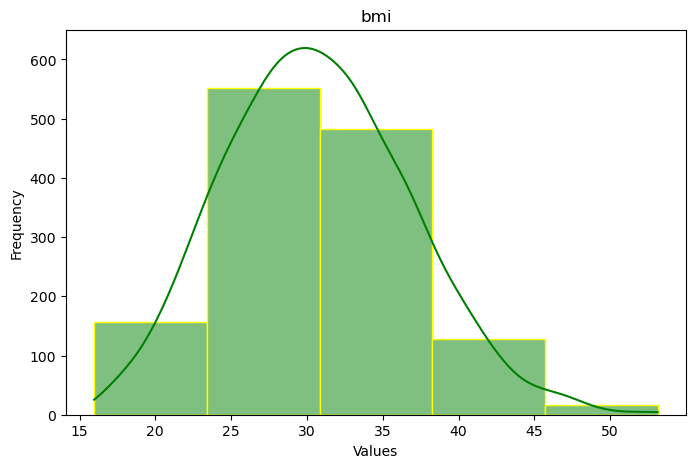

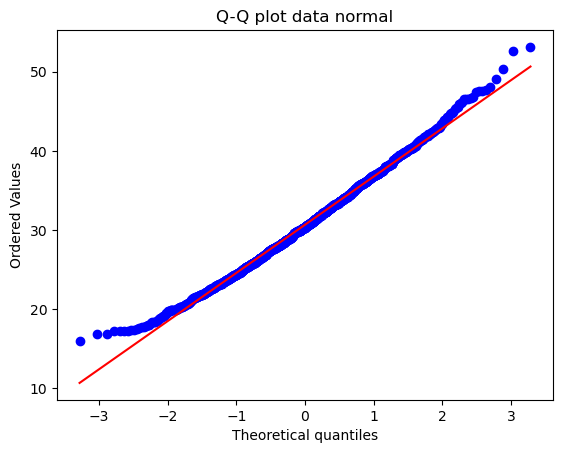

In [16]:
# Membuat histogram untuk melihat distribusi bmi
plt.figure(figsize=(8,5)) # Mengatur ukuran figure
sns.histplot(df['bmi'], bins=5, kde=True, color='green', edgecolor='yellow') # bins=5 artinya membagi bmi menjadi 5 interval
plt.xlabel('Values')   # Label sumbu X
plt.ylabel('Frequency')  # Label sumbu Y
plt.title('bmi')       # Judul histogram
plt.show()             # Menampilkan histogram

# Membuat Q-Q plot untuk memeriksa normalitas bmi
probplot(df["bmi"], dist="norm", plot=plt)  # Membandingkan distribusi bmi dengan distribusi normal
plt.title("Q-Q plot data normal")  # Judul Q-Q plot
plt.show()  # Menampilkan Q-Q plot


# Data Cleaning

## Memeriksa konsistensi data kategorikal

In [17]:
unique_data = df['sex'].unique()
print(unique_data)

['female' 'male']


In [ ]:
unique_data = df['sex'].unique()
print(unique_data)

In [18]:
unique_data1 = df['smoker'].unique()
print(unique_data1)

['yes' 'no']


In [19]:
unique_data1 = df['region'].unique()
print(unique_data1)

['southwest' 'southeast' 'northwest' 'northeast']


## Deteksi outlier menggunakan IQR

In [20]:
q1_age = df['age'].quantile(0.25)
q3_age = df['age'].quantile(0.75)
iqr_age = q3_age - q1_age

lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age

outlier_age = df[(df['age'] < lower_age) | (df['age'] > upper_age)]
outlier_age[['age']]


,age


In [21]:
q1_bmi = df['bmi'].quantile(0.25)
q3_bmi = df['bmi'].quantile(0.75)
iqr_bmi = q3_bmi - q1_bmi

lower_bmi = q1_bmi - 1.5 * iqr_bmi
upper_bmi = q3_bmi + 1.5 * iqr_bmi

outlier_bmi = df[(df['bmi'] < lower_bmi) | (df['bmi'] > upper_bmi)]
outlier_bmi[['bmi']]


,bmi
116,49.06
286,48.07
401,47.52
543,47.41
847,50.38
860,47.60
1047,52.58
1088,47.74
1317,53.13


In [22]:
jumlah_outlier_bmi = outlier_bmi.shape[0]
print(f"Jumlah data outlier pada BMI: {jumlah_outlier_bmi}")

Jumlah data outlier pada BMI: 9


In [23]:
q1_charges = df['charges'].quantile(0.25)
q3_charges = df['charges'].quantile(0.75)
iqr_charges = q3_charges - q1_charges

lower_charges = q1_charges - 1.5 * iqr_charges
upper_charges = q3_charges + 1.5 * iqr_charges

outlier_charges = df[(df['charges'] < lower_charges) | (df['charges'] > upper_charges)]
outlier_charges[['charges']]


,charges
14,39611.75770
19,36837.46700
23,37701.87680
29,38711.00000
30,35585.57600
...,...
1300,62592.87309
1301,46718.16325
1303,37829.72420
1313,36397.57600


In [24]:
jumlah_outlier_charges = outlier_charges.shape[0]
print(f"Jumlah data outlier pada charges: {jumlah_outlier_charges}")

Jumlah data outlier pada charges: 139


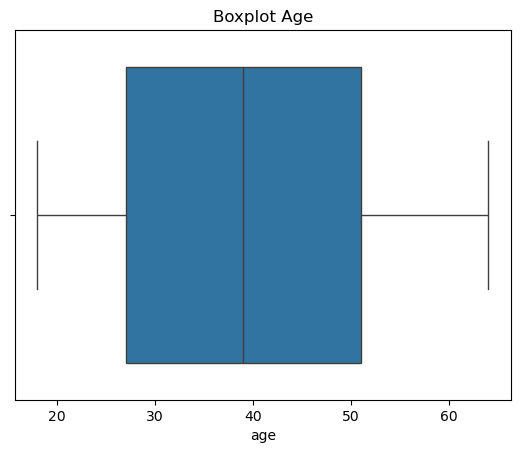

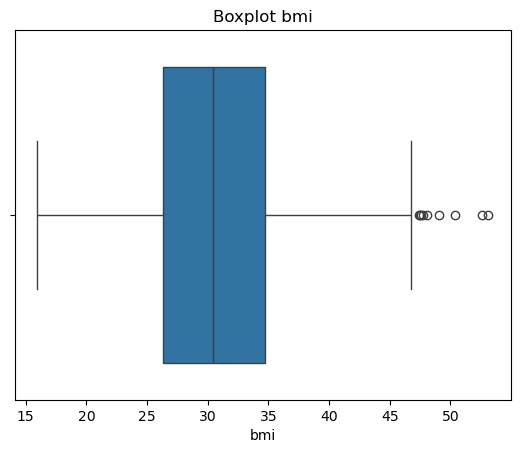

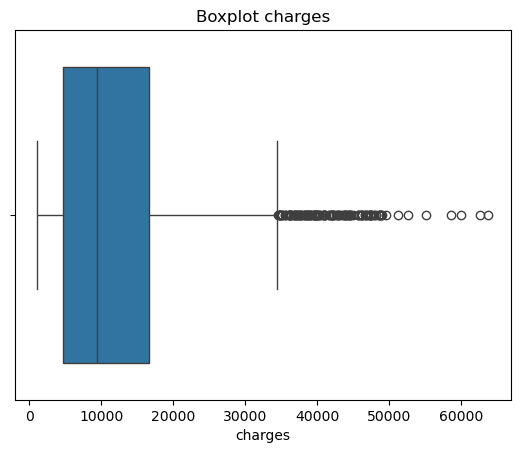

In [25]:
# Boxplot untuk kolom 'age'
sns.boxplot(x=df['age']) 
plt.title("Boxplot Age")
plt.show()

# Boxplot untuk kolom 'bmi'
sns.boxplot(x=df['bmi'])
plt.title("Boxplot bmi")
plt.show()

# Boxplot untuk kolom 'avg_glocose_level'
sns.boxplot(x=df['charges'])
plt.title("Boxplot charges")
plt.show()

Outlier pada variabel charges dipertahankan karena nilai biaya medis yang tinggi masih mencerminkan kondisi nyata pada sistem asuransi kesehatan

In [14]:
df.to_csv('insurance_clean.csv', index=False)

## Encoding

In [27]:
df_raw = df.copy()

In [28]:
encoding = [   # kolom kategorikal yang akan di encoding
    'sex',
    'smoker',
    'region'
]


label_encoders = {} # Membuat dictionary untuk menyimpan objek LabelEncoder untuk tiap kolom

for col in encoding:
    le = LabelEncoder() # Membuat instance LabelEncoder baru
    df_raw[col] = le.fit_transform(df_raw[col])
    label_encoders[col] = le   # Menyimpan LabelEncoder di dictionary supaya bisa memeriksa mapping label seperti kategori label 1 itu apa


In [29]:
df_raw.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


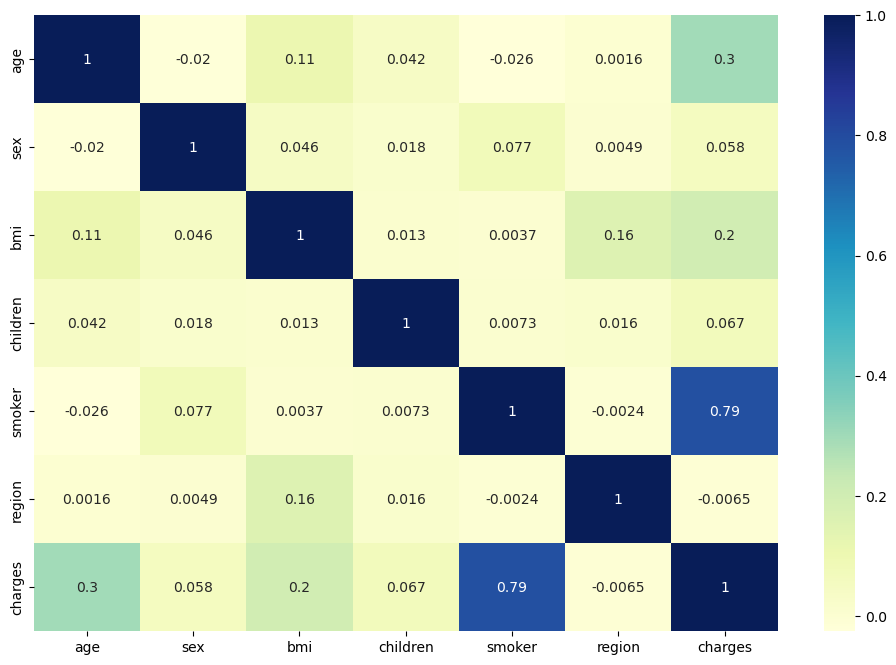

In [30]:
plt.figure(figsize=(12, 8))

# Hitung matriks korelasi
co_mtx = df_raw.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Menampilkan heatmap
plt.show()

## Analisis menggunakan group by

In [32]:
df[['bmi', 'charges']].mean()

bmi           30.663452
charges    13279.121487
dtype: float64

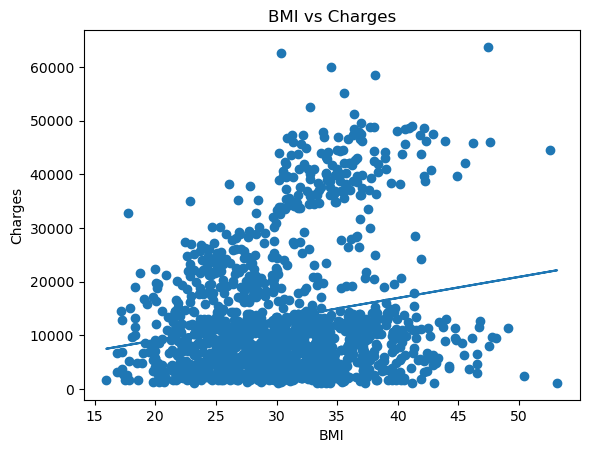

In [43]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['bmi'], df['charges'])

m, b = np.polyfit(df['bmi'], df['charges'], 1)
plt.plot(df['bmi'], m * df['bmi'] + b)

plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('BMI vs Charges')
plt.show()


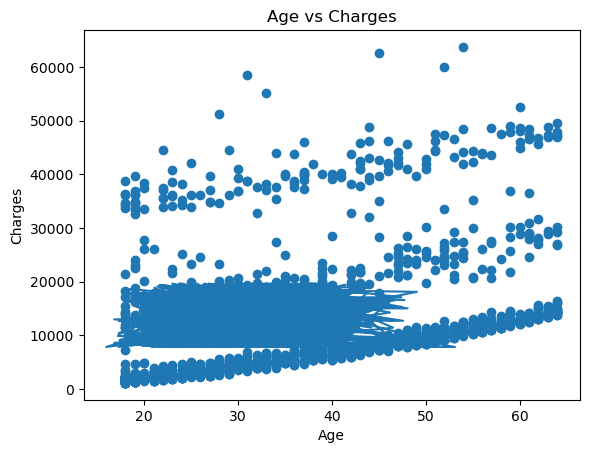

In [41]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['age'], df['charges'])

m, b = np.polyfit(df['age'], df['charges'], 1)
plt.plot(df['bmi'], m * df['age'] + b)

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges')
plt.show()


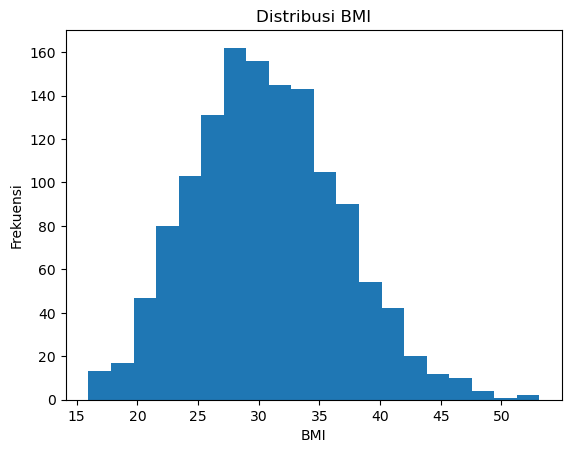

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['bmi'], bins=20)
plt.xlabel('BMI')
plt.ylabel('Frekuensi')
plt.title('Distribusi BMI')
plt.show()


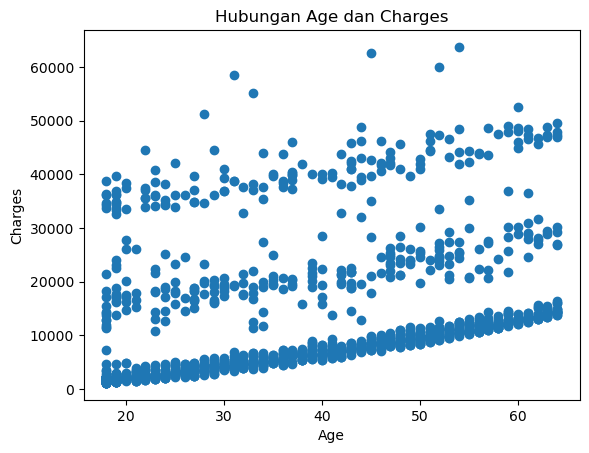

In [44]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['age'], df['charges'])
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Hubungan Age dan Charges')
plt.show()


In [38]:
df[['bmi', 'charges']].corr()


,bmi,charges
bmi,1.000000,0.198401
charges,0.198401,1.000000


In [45]:
group_mean = df.groupby("smoker",observed=True)[["age", "bmi", "charges"]].mean()
group_mean

,age,bmi,charges
smoker,,,
no,39.404516,30.651853,8440.660307
yes,38.514599,30.708449,32050.231832


In [46]:
group_mean = df.groupby("region",observed=True)[["age", "bmi", "charges"]].mean()
group_mean

,age,bmi,charges
region,,,
northeast,39.268519,29.173503,13406.384516
northwest,39.259259,29.195494,12450.840844
southeast,38.939560,33.355989,14735.411438
southwest,39.455385,30.596615,12346.937377
